#Top

[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/statistical_analysis/matching_propensity_scores)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/statistical_analysis/matching_propensity_scores/matching_propensity_scores_r_google_colab.ipynb)

#Matching with Propensity Scores

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Matching%20with%20Propensity%20Scores.png)

**analysis**
*   This propensity score matching analysis is performed on the "Impact of Remote Work on Mental Health" (synthetic) dataset from Kaggle. I am estimating the causal effect of working fully remote on work life balance in North America. Here, I am using "Remote" as treatment vs. "Onsite" or "Hybrid" as control and Work-Life Balance Rating as the outcome. This quasiexperiment is done with observational methods, as the data was not generated using a randomized A/B test.

**result**
*  It was established that there was not a significant causal effect of working fully remote on work-life balance based on the observational study (-0.16 difference in work-life balance rating for Remote, but NO signficance).

**recommendation**
*  Based on the observational study / propensity score matching analysis, I do not recommend that employees choose work location (remove vs. onsite) specifically in order to improve their work-life balance, as there is not sufficient evidence of its impact.

# Setup

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Setup.png)

## Install Packages

In [1]:
install.packages("tableone")
install.packages("Matching")
install.packages("MatchIt")
install.packages("sysfonts")
install.packages("showtext")
install.packages("ggplot2")
install.packages("optmatch")
install.packages("sensitivitymv")

## Load Libraries

In [ ]:
library(tableone)
library(Matching)
library(MatchIt)
library(sysfonts)
library(showtext)
library(ggplot2)
library(dplyr)
library(optmatch)
library(sensitivitymv)

#Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Import%20Data.png)

Import data from Github repo:

In [3]:
mydata <- read.csv("https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/main/1_projects/statistical_analysis/matching_propensity_scores/remote_work.csv",stringsAsFactors = T)

## View Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/View%20Data.png)

The data have n=5000 employees and 20 variables:

In [4]:
dim(mydata)

[1] 5000   20

In [5]:
head(mydata)

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
1,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
2,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
3,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,None,Poor,North America
4,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,None,Poor,Europe
5,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,None,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America
6,EMP0006,59,Non-binary,Sales,IT,31,Hybrid,39,3,4,High,None,No,Increase,5,Unsatisfied,1,None,Average,South America


In [6]:
tail(mydata)

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
4995,EMP4995,40,Prefer not to say,Marketing,IT,17,Hybrid,52,1,2,Medium,Burnout,Yes,Increase,3,Neutral,5,Daily,Good,Oceania
4996,EMP4996,32,Male,Sales,Consulting,4,Onsite,24,2,5,High,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average,Asia
4997,EMP4997,39,Female,Sales,Healthcare,27,Onsite,48,15,1,Low,Depression,Yes,Decrease,1,Satisfied,1,None,Average,Africa
4998,EMP4998,42,Female,Sales,Healthcare,21,Hybrid,34,1,4,High,Burnout,No,Increase,3,Satisfied,1,Daily,Poor,Oceania
4999,EMP4999,27,Female,Sales,Healthcare,26,Remote,58,0,5,Low,None,Yes,Increase,3,Unsatisfied,4,Daily,Average,Asia
5000,EMP5000,29,Male,HR,IT,30,Onsite,20,15,1,Low,Depression,Yes,No Change,3,Unsatisfied,5,None,Poor,Asia


Variable definitions:

Note, this is the original version of the dataset, which includes more fields than that of the version that is currently on Kaggle.

*   Employee_ID – Unique identifier for each synthetic employee
*   Age – Age of employee
*   Gender – Gender representation
*   Job_Role – Assigned job role
*   Years of Experience – # of years of work experience in role
*   Industry – Simulated industry category
*   Work_Location – Work setting: Remote, Hybrid, or Onsite
*   Hours_Worked_per_Week - # of hours worked/week
*   Number_of_Virtual_Meetings  - # of zoom meetings
*   Work-Life Balance Rating - Simulated rating (1-5)
*   Stress_Level – Modeled self-reported stress level (Low, Medium, High)
*   Mental_Health_Condition – Synthetic responses for mental health conditions (e.g., Anxiety, Depression, Burnout, None)
*   Access to Mental Health Resources (Yes, No)
*   Productivity_Change (Increase, Decrease, No Change)
*   Social_Isolation_Rating – Simulated rating (1-5) on workplace isolation perception
*   Satisfaction_with_Remote_Work – Modeled employee satisfaction with remote work (Satisfied, Neutral, Unsatisfied)
*   Company_Support_for_Remote_Work -Simulated rating (1-5)
*   Physical_Activity - Daily, Weekly, None
*   Sleep_Quality - Good, Average, Poor
*   Region - Continent


*   Treatment (treat): Remote (1) vs. Onsite or Hybrid (0)
*   Outcome: Work-Life Balance Score (1-5)

Limit data to North America:

In [7]:
mydata <- mydata[mydata$Region == "North America", ]

Remove Region field as no longer needed:

In [8]:
mydata <- mydata[,!names(mydata)=="Region"]

In [9]:
mydata <- mydata[order(mydata$Work_Location), ]

Manually create imbalance for demonstration purposes as one does not actually exist with the original data:

In [10]:
mydata$Job_Role[1:30] <- "Marketing"
mydata$Physical_Activity[1:60] <- "Weekly"

mydata$Job_Role[31:60] <- "Software Engineer"
mydata$Access_to_Mental_Health_Resources[1:100] <- "Yes"


The new dimensions after limiting to North America, there are 777 observations (employees) and 19 variables:

In [11]:
dim(mydata)

[1] 777  19

Check for null values:

In [12]:
anyNA(mydata)

[1] FALSE

View datatypes:

In [13]:
sapply(mydata, class)

Employee_ID                               Age 
                         "factor"                         "integer" 
                           Gender                          Job_Role 
                         "factor"                          "factor" 
                         Industry               Years_of_Experience 
                         "factor"                         "integer" 
                    Work_Location             Hours_Worked_Per_Week 
                         "factor"                         "integer" 
       Number_of_Virtual_Meetings          Work_Life_Balance_Rating 
                        "integer"                         "integer" 
                     Stress_Level           Mental_Health_Condition 
                         "factor"                          "factor" 
Access_to_Mental_Health_Resources               Productivity_Change 
                         "factor"                          "factor" 
          Social_Isolation_Rating     Satisfaction_with_Remote_Work 
                        "integer"                          "factor" 
  Company_Support_for_Remote_Work                 Physical_Activity 
                        "integer"                          "factor" 
                    Sleep_Quality 
                         "factor"

#Pre-processing

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Pre-Processing.png)

Drop Employee_ID (not needed) & Productivity Change (related to outcome) & Satisfaction with Remote Work (related to outcome) & Industry (correlation with Job Role), Company Support for Remote Work (unclear if it came before or after treatment/outcome), Stress Level  & Mental_Health_Condition & Social Isolation Rating (would be alternative outcomes):

In [14]:
mydata <- mydata[ , !names(mydata) %in%
                   c("Employee_ID","Productivity_Change","Satisfaction_with_Remote_Work",
                     "Company_Support_for_Remote_Work","Industry","Stress_Level","Mental_Health_Condition",
                     "Social_Isolation_Rating")]

View unique values of variables:

In [15]:
unique(mydata["Job_Role"])

,Job_Role
,<fct>
3,Marketing
585,Software Engineer
1043,Sales
1139,Designer
1151,Project Manager
1235,Data Scientist
1410,HR


In [16]:
unique(mydata["Work_Location"])

,Work_Location
,<fct>
3,Hybrid
5,Onsite
25,Remote


In [17]:
unique(mydata["Access_to_Mental_Health_Resources"])

,Access_to_Mental_Health_Resources
,<fct>
3,Yes
1852,No


In [18]:
unique(mydata["Physical_Activity"])

,Physical_Activity
,<fct>
3,Weekly
1043,None
1151,Daily


In [19]:
unique(mydata["Gender"])

,Gender
,<fct>
3,Non-binary
10,Female
32,Prefer not to say
158,Male


In [20]:
unique(mydata["Sleep_Quality"])

,Sleep_Quality
,<fct>
3,Poor
32,Average
83,Good


In [21]:
print(sapply(mydata, class))

                              Age                            Gender 
                        "integer"                          "factor" 
                         Job_Role               Years_of_Experience 
                         "factor"                         "integer" 
                    Work_Location             Hours_Worked_Per_Week 
                         "factor"                         "integer" 
       Number_of_Virtual_Meetings          Work_Life_Balance_Rating 
                        "integer"                         "integer" 
Access_to_Mental_Health_Resources                 Physical_Activity 
                         "factor"                          "factor" 
                    Sleep_Quality 
                         "factor" 


Use above as reference to create dummy variables & format others:

In [22]:
mydata$mh_access<-as.numeric(mydata$Access_to_Mental_Health_Resources=="Yes")

mydata$software_engineer_role<-as.numeric(mydata$Job_Role=="Software Engineer")
mydata$sales_role<-as.numeric(mydata$Job_Role=="Sales")
mydata$data_scientist_role<-as.numeric(mydata$Job_Role=="Data Scientist")
mydata$hr_role<-as.numeric(mydata$Job_Role=="HR")
mydata$designer_role<-as.numeric(mydata$Job_Role=="Designer")
mydata$product_manager_role<-as.numeric(mydata$Job_Role=="Product Manager")
mydata$marketing_role<-as.numeric(mydata$Job_Role=="Marketing")

mydata$treat<- as.numeric(mydata$Work_Location=="Remote")

mydata$age<-mydata$Age
mydata$work_life_balance_rating<-mydata$Work_Life_Balance_Rating

mydata$female<-as.numeric(mydata$Gender=="Female")
mydata$male<-as.numeric(mydata$Gender=="Male")
mydata$nonbinary<-as.numeric(mydata$Gender=="Non-binary")
mydata$gender_prefernotsaid<-as.numeric(mydata$Gender=="Prefer not to say")

mydata$weekly_exercise<-as.numeric(mydata$Physical_Activity=="Weekly")
mydata$daily_exercise<-as.numeric(mydata$Physical_Activity=="Daily")
mydata$no_exercise<-as.numeric(mydata$Physical_Activity=="None")

mydata$good_sleep<-as.numeric(mydata$Sleep_Quality=="Good")
mydata$average_sleep<-as.numeric(mydata$Sleep_Quality=="Average")
mydata$poor_sleep<-as.numeric(mydata$Sleep_Quality=="Poor")

mydata$num_virt_mtngs<-mydata$Number_of_Virtual_Meetings
mydata$weekly_hrs_worked<-mydata$Hours_Worked_Per_Week
mydata$yrs_exp<-mydata$Years_of_Experience

Assign x variables:

In [23]:
xvars=c("age","mh_access","software_engineer_role","sales_role","data_scientist_role",
        "hr_role","designer_role","product_manager_role","marketing_role","female","male","nonbinary",
        "gender_prefernotsaid","weekly_exercise","daily_exercise","no_exercise",
        "good_sleep","average_sleep","poor_sleep","num_virt_mtngs","weekly_hrs_worked",
        "yrs_exp")

View summary statistics:

In [24]:
summary(mydata)

      Age                      Gender                 Job_Role  
 Min.   :22.00   Female           :201   Data Scientist   : 95  
 1st Qu.:30.00   Male             :199   Designer         :100  
 Median :41.00   Non-binary       :192   HR               :117  
 Mean   :40.79   Prefer not to say:185   Marketing        :130  
 3rd Qu.:50.00                           Project Manager  :112  
 Max.   :60.00                           Sales            : 96  
                                         Software Engineer:127  
 Years_of_Experience Work_Location Hours_Worked_Per_Week
 Min.   : 1.00       Hybrid:261    Min.   :20.00        
 1st Qu.: 9.00       Onsite:252    1st Qu.:29.00        
 Median :18.00       Remote:264    Median :40.00        
 Mean   :17.93                     Mean   :39.74        
 3rd Qu.:27.00                     3rd Qu.:50.00        
 Max.   :35.00                     Max.   :60.00        
                                                        
 Number_of_Virtual_Meeti

#Standardized differences

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Standardized%20Differences.png)

Compute difference in means for each x variable, between groups. The groups are control (0) vs. treatment (1). Formula: (mean x_treatment - mean_x_control) / (square root ((s_squared_treatment+s_squared_control) / 2)) where s is the pooled standard deviation.

*   smd < 0.1 signals adequate balance
*   smd > 0.2 signals serious imbalance

There is serious imbalance in some covariates between the groups (some are above 0.2):

In [25]:
table1<-CreateTableOne(vars=xvars,strata="treat",data=mydata, test=FALSE)
print(table1,smd=TRUE)

                                    Stratified by treat
                                     0             1             SMD   
  n                                    513           264               
  age (mean (SD))                    40.66 (11.42) 41.06 (11.39)  0.035
  mh_access (mean (SD))               0.58 (0.49)   0.48 (0.50)   0.201
  software_engineer_role (mean (SD))  0.19 (0.39)   0.12 (0.33)   0.178
  sales_role (mean (SD))              0.12 (0.33)   0.13 (0.34)   0.024
  data_scientist_role (mean (SD))     0.11 (0.31)   0.15 (0.36)   0.115
  hr_role (mean (SD))                 0.15 (0.36)   0.16 (0.36)   0.020
  designer_role (mean (SD))           0.11 (0.31)   0.17 (0.37)   0.167
  product_manager_role (mean (SD))    0.00 (0.00)   0.00 (0.00)  <0.001
  marketing_role (mean (SD))          0.19 (0.39)   0.12 (0.33)   0.193
  female (mean (SD))                  0.26 (0.44)   0.27 (0.44)   0.022
  male (mean (SD))                    0.26 (0.44)   0.25 (0.44)   0.008
  nonbin

Outcome (y) of Work-Life Balance Rating for Treatment= Remote or Hybrid (vs. Onsite=No Treatment):

In [26]:
y_trt<-mydata$work_life_balance_rating[mydata$treat==1]
print(head(y_trt))

[1] 3 2 2 3 2 2


Control Work-Life Balance Rating:

In [27]:
y_con<-mydata$work_life_balance_rating[mydata$treat==0]
print(head(y_con))

[1] 5 1 1 2 3 3


Difference between treatment & control:

Raw/unadjusted mean differnce of work-life balance rating for treated vs. control (Work-Life Balance Rating for Remote workers is lower (by .14) than that of Onsite workers):


In [28]:
mean(y_trt)-mean(y_con)

[1] -0.1444932

#Propensity scores

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Propensity%20Scores.png)

Use logistic regression to calculate propensity scores. This regresses the treatment on the x variables:

Dropped variables ("gender_prefernotsaid","no_exercise","product_manager_role","poor_sleep") to create reference variables because they are dummy variables and therefore one of the groups needs to be left out in regression to have meaning:

In [29]:
print(xvars)

 [1] "age"                    "mh_access"              "software_engineer_role"
 [4] "sales_role"             "data_scientist_role"    "hr_role"               
 [7] "designer_role"          "product_manager_role"   "marketing_role"        
[10] "female"                 "male"                   "nonbinary"             
[13] "gender_prefernotsaid"   "weekly_exercise"        "daily_exercise"        
[16] "no_exercise"            "good_sleep"             "average_sleep"         
[19] "poor_sleep"             "num_virt_mtngs"         "weekly_hrs_worked"     
[22] "yrs_exp"               


In [30]:
psmodel<-glm(treat~age + mh_access + software_engineer_role + sales_role + data_scientist_role +
        hr_role + designer_role + marketing_role + female + male +
        nonbinary + weekly_exercise + daily_exercise + weekly_hrs_worked +
        yrs_exp + num_virt_mtngs + good_sleep + average_sleep, family=binomial(), data=mydata)
summary(psmodel)


Call:
glm(formula = treat ~ age + mh_access + software_engineer_role + 
    sales_role + data_scientist_role + hr_role + designer_role + 
    marketing_role + female + male + nonbinary + weekly_exercise + 
    daily_exercise + weekly_hrs_worked + yrs_exp + num_virt_mtngs + 
    good_sleep + average_sleep, family = binomial(), data = mydata)

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)  
(Intercept)            -0.776696   0.525545  -1.478   0.1394  
age                     0.005003   0.006925   0.722   0.4700  
mh_access              -0.269276   0.159144  -1.692   0.0906 .
software_engineer_role -0.323999   0.295212  -1.098   0.2724  
sales_role             -0.029330   0.297183  -0.099   0.9214  
data_scientist_role     0.288404   0.293466   0.983   0.3257  
hr_role                 0.011547   0.282328   0.041   0.9674  
designer_role           0.430188   0.288552   1.491   0.1360  
marketing_role         -0.465510   0.290572  -1.602   0.1091  
female     

Extracts propensity score values:

In [31]:
pscore<-psmodel$fitted.values

In [32]:
min(round(pscore,4))
max(round(pscore,4))
length(pscore)

[1] 0.1111

[1] 0.7043

[1] 777

Print coefficients with clearer/expanded numbers:

In [33]:
print(coef(psmodel))

           (Intercept)                    age              mh_access 
          -0.776695947            0.005002667           -0.269276076 
software_engineer_role             sales_role    data_scientist_role 
          -0.323998785           -0.029329713            0.288404195 
               hr_role          designer_role         marketing_role 
           0.011547314            0.430188105           -0.465509825 
                female                   male              nonbinary 
          -0.059217956           -0.113663675           -0.256985968 
       weekly_exercise         daily_exercise      weekly_hrs_worked 
          -0.426727007            0.316435169            0.002654734 
               yrs_exp         num_virt_mtngs             good_sleep 
          -0.005850215            0.040372542           -0.050104998 
         average_sleep 
          -0.185746308 


Add propensity scores into the data:

In [34]:
mydata <- cbind(mydata, pscore)

View propensity score distributions between treatment vs. control groups:

This histogram shows that the groups have a bit different distributions and would benefit from matching to achieve balance:

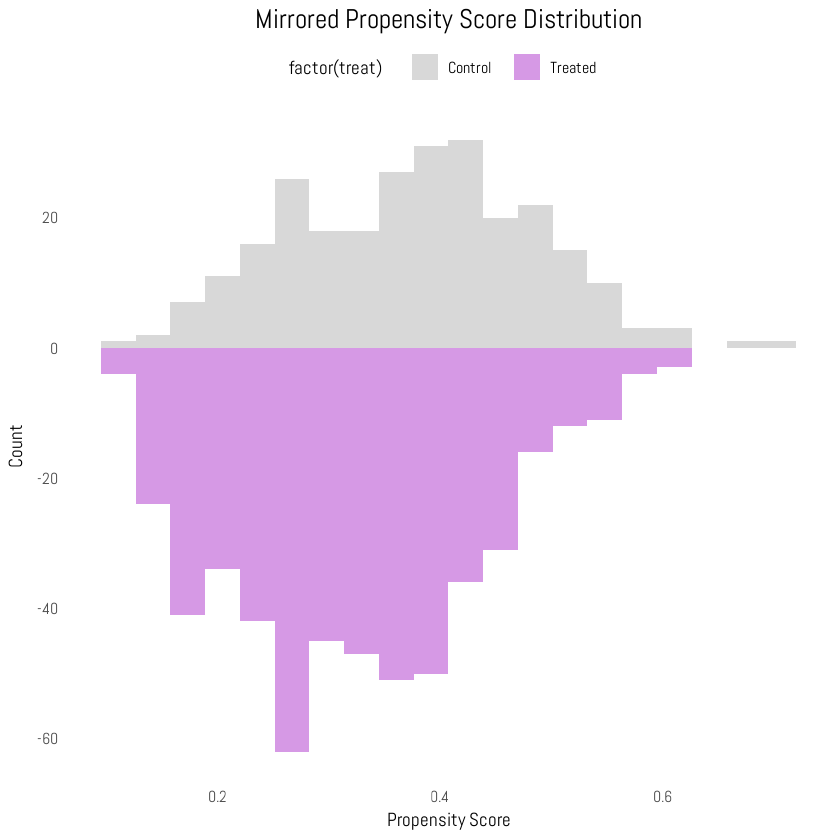

In [35]:
df <- data.frame(ps = pscore, treat = factor(mydata$treat))

font_add_google("Abel", "abel")
showtext_auto()

suppressWarnings(ggplot(df, aes(x = ps, fill = factor(treat))) +
  geom_histogram(
    data = subset(df, treat == 1),
    bins = 20, alpha = 0.6
  ) +
  geom_histogram(
    data = subset(df, treat == 0),
    bins = 20, alpha = 0.6,
    aes(y = -after_stat(count)) # flip control group to negative y
  ) +
  labs(title = "Mirrored Propensity Score Distribution",
       x = "Propensity Score", y = "Count") +
  scale_fill_manual(values = c("gray", "mediumorchid"),
                    labels = c("Control", "Treated")) +
  theme_minimal()+
  theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
  theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    legend.position = "top",
    legend.title = element_text(size = 14, face = "bold", family = "abel"),
    legend.text = element_text(size = 12, family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
))

#Matching

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Matching.png)

Match treatment subjects with control subjects based on similar propensity scores:

*   Pair matching, without replacement, no caliper.
*   Matched on the propensity score itself (not logit of the propensity score)

Obtained the standardized differences for the matched data. Note that none are above 0.1, so a caliper is not needed. A caliper is a maximum acceptable distance of the best match, so it would help reduce the smds if they were too high (>0.2).

There were 252 (control) and 264 (treated), totaling 516 employees (from "n" in smd chart above), therefore it made 264 matches below:

In [36]:
set.seed(100)

psmatch<-Match(Tr=mydata$treat,M=1,X=pscore,replace=FALSE)
matched<-mydata[unlist(psmatch[c("index.treated","index.control")]),]
matchedtab<-CreateTableOne(vars=xvars,strata="treat",data=matched,test=FALSE)
print(matchedtab,smd=TRUE)

                                    Stratified by treat
                                     0             1             SMD   
  n                                    264           264               
  age (mean (SD))                    40.93 (11.23) 41.06 (11.39)  0.011
  mh_access (mean (SD))               0.48 (0.50)   0.48 (0.50)  <0.001
  software_engineer_role (mean (SD))  0.09 (0.29)   0.12 (0.33)   0.098
  sales_role (mean (SD))              0.14 (0.35)   0.13 (0.34)   0.044
  data_scientist_role (mean (SD))     0.16 (0.36)   0.15 (0.36)   0.021
  hr_role (mean (SD))                 0.16 (0.36)   0.16 (0.36)  <0.001
  designer_role (mean (SD))           0.18 (0.39)   0.17 (0.37)   0.040
  product_manager_role (mean (SD))    0.00 (0.00)   0.00 (0.00)  <0.001
  marketing_role (mean (SD))          0.11 (0.32)   0.12 (0.33)   0.023
  female (mean (SD))                  0.28 (0.45)   0.27 (0.44)   0.026
  male (mean (SD))                    0.28 (0.45)   0.25 (0.44)   0.060
  nonbin

View matched pairs, showing their pair_id and their propensity scores:

In [37]:
# Group treated vs. control
treated  <- mydata[psmatch$index.treated, ]
control  <- mydata[psmatch$index.control, ]

# Add ID for each treated/control pair
# Indices were already ordered in matching order for treatment & control in matching function
pair_id <- seq_along(psmatch$index.treated)
treated$pair_id <- pair_id
control$pair_id <- pair_id

# Add propensity score
treated$pscore <- pscore[psmatch$index.treated]
control$pscore <- pscore[psmatch$index.control]

matched_pairs <- merge(
  treated[, c("pair_id", "treat", "pscore")],
  control[, c("pair_id", "treat", "pscore")],
  by = "pair_id",
  suffixes = c(".treated", ".control")
)

head(matched_pairs)

,pair_id,treat.treated,pscore.treated,treat.control,pscore.control
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,0.5510691,0,0.5501304
2,2,1,0.2419249,0,0.2414837
3,3,1,0.4735577,0,0.4743751
4,4,1,0.3018724,0,0.3017638
5,5,1,0.3577197,0,0.3589932
6,6,1,0.4750771,0,0.4743643


Add outcome (work_life_balance_rating) to table, to be used in a later section below:

In [59]:
matched_pairs_w_outcome <- merge(
  treated[, c("pair_id", "treat", "pscore", "work_life_balance_rating")],
  control[, c("pair_id", "treat", "pscore", "work_life_balance_rating")],
  by = "pair_id",
  suffixes = c(".treated", ".control")
)

head(matched_pairs_w_outcome)

,pair_id,treat.treated,pscore.treated,work_life_balance_rating.treated,treat.control,pscore.control,work_life_balance_rating.control
,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>
1,1,1,0.5510691,3,0,0.5501304,2
2,2,1,0.2419249,2,0,0.2414837,2
3,3,1,0.4735577,2,0,0.4743751,1
4,4,1,0.3018724,3,0,0.3017638,5
5,5,1,0.3577197,2,0,0.3589932,3
6,6,1,0.4750771,2,0,0.4743643,4


Reformat chart for updated histogram of propensity score distribution:

In [39]:
treat_vec <- rep(1, length(psmatch$index.treated))
control_vec <- rep(0, length(psmatch$index.control))

df_matched <- data.frame(
  pair_id,
  treat   = c(treat_vec, control_vec),
  pscore  = c(pscore[psmatch$index.treated], pscore[psmatch$index.control])
)

head(df_matched)


,pair_id,treat,pscore
,<int>,<dbl>,<dbl>
25,1,1,0.5510691
30,2,1,0.2419249
33,3,1,0.4735577
34,4,1,0.3018724
46,5,1,0.3577197
62,6,1,0.4750771


Make chart for matched that can go into histogram. pscore & treated vs. control only

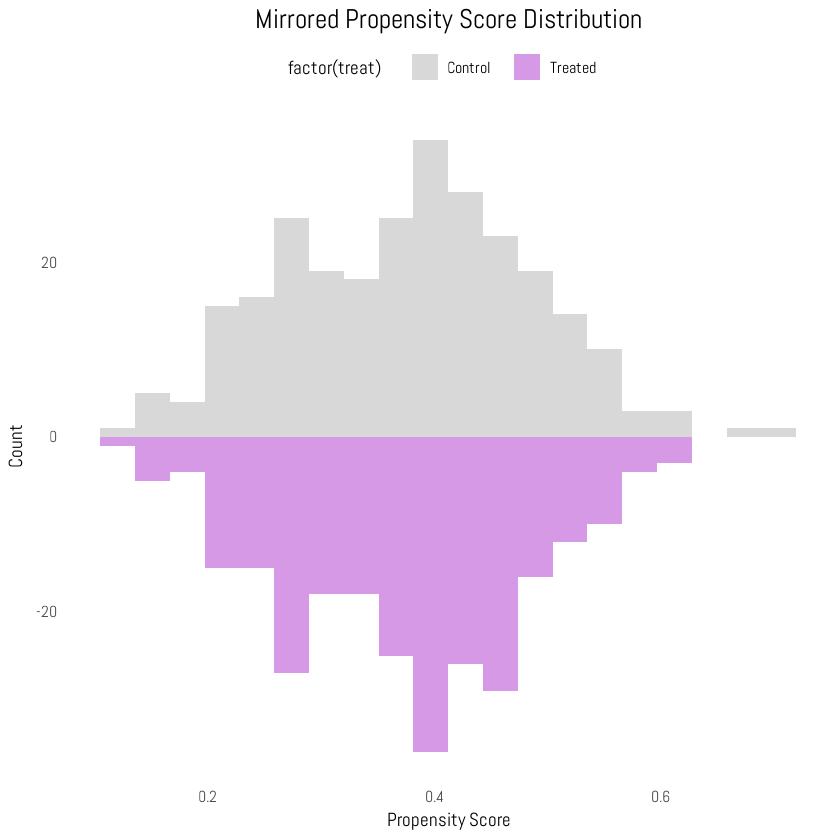

In [40]:
ggplot(df_matched, aes(x = pscore, fill = factor(treat))) +
  geom_histogram(
    data = subset(df_matched, treat == 1),
    bins = 20, alpha = 0.6
  ) +
  geom_histogram(
    data = subset(df_matched, treat == 0),
    bins = 20, alpha = 0.6,
    aes(y = after_stat(-count))   # flip control group to negative y
  ) +
  labs(title = "Mirrored Propensity Score Distribution",
       x = "Propensity Score", y = "Count") +
  scale_fill_manual(values = c("gray", "mediumorchid"),
                    labels = c("Control", "Treated")) +
  theme_minimal()+
  theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
  theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    legend.position = "top",
    legend.title = element_text(size = 14, face = "bold", family = "abel"),
    legend.text = element_text(size = 12, family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
)

#Results

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results.png)

Label treatment subjects:

In [41]:
matched$treat<-as.numeric(matched$treat==1)

Work-Life Balance Rating for treated & control subjects (displayed separately & just the first few):

In [42]:
y_trt_matched<-matched$work_life_balance_rating[matched$treat==1]
head(y_trt_matched)

[1] 3 2 2 3 2 2

In [43]:
y_con_matched<-matched$work_life_balance_rating[matched$treat==0]
head(y_con_matched)

[1] 2 2 1 5 3 4

Confirming length of each (264) matches up with 264 pairs:

In [44]:
length(y_con_matched)

[1] 264

Mean work-life balance rating for treated & control:

In [45]:
mean(y_trt_matched)

[1] 2.875

In [46]:
mean(y_con_matched)

[1] 3.030303

Difference in average work-life balance rating between treated vs. control subjects is -1.6:

In [47]:
mean(y_trt_matched)-mean(y_con_matched)

[1] -0.155303

In [48]:
diffy<-y_trt_matched-y_con_matched

In [49]:
print(head(diffy))

[1]  1  0  1 -2 -1 -2


##Significance

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Significance.png)

A t-Test was performed to compare the difference between the two means:

For matched data, the difference in means of work-life balance rating for treated vs. control is -0.16. This result is not signficant given the p-value of 0.21.



95% confidence interval is also ~ -0.40-0.09, and therefore it includes 0, meaning there is no strong evidence in a difference in the means between treatment vs. control in the matched data

"diffy" is already the paired difference, so a simple one-sample t-test on diffy is equivalent to a paired t-test.

In [50]:
t.test(diffy)


	One Sample t-test

data:  diffy
t = -1.2518, df = 263, p-value = 0.2117
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -0.39958173  0.08897566
sample estimates:
mean of x 
-0.155303 


#Sensitivity Analysis

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Sensitivity%20Analysis.png)

Rosenbaum's Gamma test tests for unobserved confounding by seeing how easily the conclusion would change if the odds of treatment of treatment vs. control changed (e.g., if a small change (in gamma: ratio (in a match of person j & k) person j's odds to treatment person k's odds of treatment) changes the conclusion then it’s very sensitive).

This is more important if the result is significant. In this case the result was not significant, but the below sensitivity test also validates it's not masking a hidden effect.

In [51]:
# matched_pairs_w_outcome = dataframe of matched pairs from before
# y = matrix with treated and control outcomes per row

y <- cbind(
  matched_pairs_w_outcome$work_life_balance_rating.treated,
  matched_pairs_w_outcome$work_life_balance_rating.control
)


Confirm same #s from table above:

In [52]:
head(y)

3,2
2,2
2,1
3,5
2,3
2,4


Test gamma of 1.5 (vs. 1 - no difference in odds):

In [53]:
library(sensitivitymv)

senmv(y, gamma = 1.5)


$pval
[1] 0.9999389

$deviate
[1] -3.841822

$statistic
[1] -5.7

$expectation
[1] 14.42

$variance
[1] 27.4272

Tested more gamma values and none of them had significant p-value:

In [54]:
# for (g in seq(1, 3, 0.1)) {
#   cat("Gamma =", g, "\n")
#   print(senmv(y, gamma = g))
# }


#Randomization/Permutation Tests

Test how likely the result could've come from random chance:

When treatment labels were randomly shuffled 1,000x, 21% of the random shuffles produced an average difference at least as large or larger in magnitude as the -0.16 difference, showing the difference could easily arise by chance (p-value: 0.21>0.05).    

The difference was not siginficant to begin with, and the permutation test also supports that the difference is not significant.


In [55]:
# Per-pair differences
matched_pairs_w_outcome$diff <- matched_pairs_w_outcome$work_life_balance_rating.treated - matched_pairs_w_outcome$work_life_balance_rating.control

# Observed mean difference
obs_diff <- mean(matched_pairs_w_outcome$diff)
cat("Observed mean difference (treated - control):", obs_diff, "\n")

# Permutation test
set.seed(100)
n_iter <- 1000
perm_diffs <- numeric(n_iter)

for (i in 1:n_iter) {
  # Randomly flip the sign of the pair differences (simulates swapping treatment labels)
  flip <- sample(c(-1, 1), nrow(matched_pairs_w_outcome), replace = TRUE)
  perm_diffs[i] <- mean(matched_pairs_w_outcome$diff * flip)
}

# Observed vs. permutation distribution
p_value <- mean(abs(perm_diffs) >= abs(obs_diff))
cat("Permutation p-value:", p_value, "\n")


Observed mean difference (treated - control): -0.155303 
Permutation p-value: 0.209 


This chart visually shows the treatment effect is not statistically signficant. It is showing the permutation of 1,000 random shuffles and that the 21% of differences/shuffles that are below the -0.16 observed difference (the grey bars to the left of the observed purple bar).

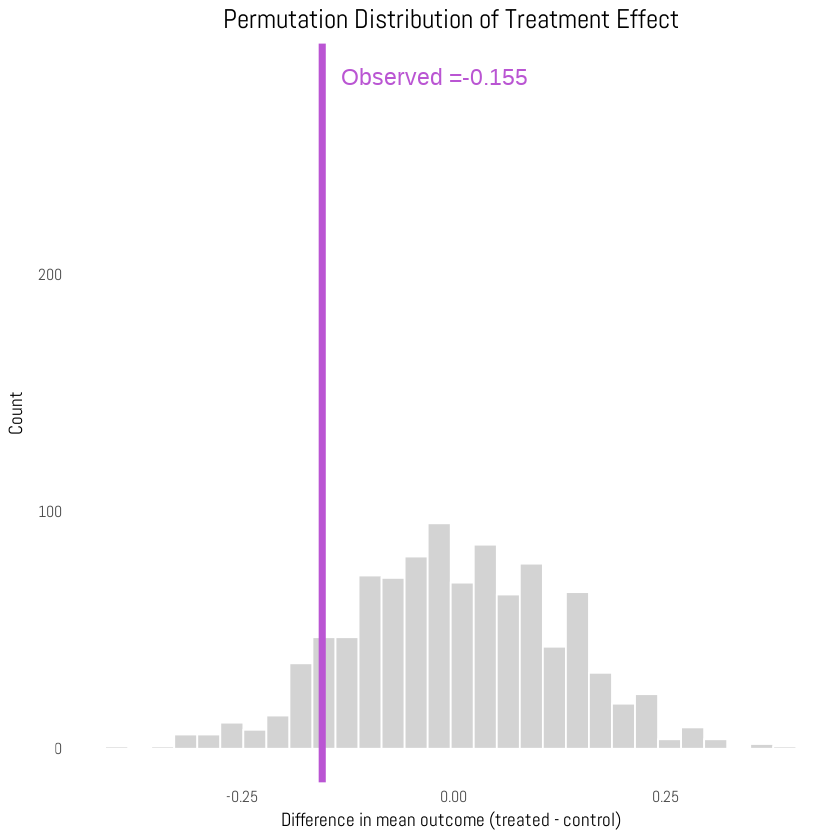

In [56]:
perm_df <- data.frame(perm_diffs = perm_diffs)

suppressWarnings(ggplot(perm_df, aes(x = perm_diffs)) +
  geom_histogram(bins = 30, fill = "lightgray", color = "white") +
  geom_vline(xintercept = obs_diff, color = "mediumorchid", size = 2) +
  annotate("text", x = obs_diff,
           y = max(hist(perm_diffs, plot = FALSE)$counts),
           label = paste0("Observed =", round(obs_diff, 3)),
           hjust = -.1, color = "mediumorchid", size =6) +
  labs(
    title = "Permutation Distribution of Treatment Effect",
    x = "Difference in mean outcome (treated - control)",
    y = "Count"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
  ))


Perform sensitivity analysis testing a different matching method "optimal" (vs. "nearest neighbor in above) using Optmatch package, which minimizes the total distance across all matches:

 This analysis also shows the conclusion still holds with Optimal matching (p-value still showing no significance):

In [57]:
psm_optimal_optmatch <- function(data, treatment, xvars, outcome) {
  set.seed(100)

  # Distance matrix
  dist_mat <- match_on(as.formula(paste(treatment, "~ pscore")), data = data)

  # Optimal pair matching
  matches <- pairmatch(dist_mat, data = data)

  # Pair IDs as integers
  data$pair_id <- as.numeric(as.factor(matches))

  # Drop umatched units
  matched <- subset(data, !is.na(pair_id))

  # Numeric treatment indicator
  matched$treat_num <- as.numeric(matched[[treatment]] == 1)

  # SMD table (including max SMD)
  tab <- CreateTableOne(vars = xvars, strata = treatment, data = matched, test = FALSE)
  smd_vals <- ExtractSmd(tab)
  smd_vals[!is.finite(smd_vals)] <- NA
  max_smd <- if(length(smd_vals) == 0) NA else max(abs(smd_vals), na.rm = TRUE)

  # Matched pairs table
  treated <- matched[matched$treat_num == 1, ]
  control <- matched[matched$treat_num == 0, ]

  merged <- merge(
    treated[, c("pair_id", treatment, outcome, "pscore")],
    control[, c("pair_id", treatment, outcome, "pscore")],
    by = "pair_id",
    suffixes = c(".treated", ".control")
  )

  # Paired differences
  diffy <- merged[[paste0(outcome, ".treated")]] - merged[[paste0(outcome, ".control")]]

  treat_effect <- mean(diffy)
  p_value <- t.test(diffy)$p.value
  merged$observed_diff <- diffy

  # Output
  return(list(
    summary = data.frame(
      n_matched_pairs = nrow(merged),
      treat_effect = round(treat_effect, 3),
      p_value = p_value,
      max_smd = max_smd
    ),
    matched_pairs_details = merged,
    matched_long = matched[, c("pair_id", treatment, "pscore", outcome, xvars)]
  ))
}


P-value is still not significant at 0.17, showing that the original conclusion holds:

In [58]:
result <- psm_optimal_optmatch(
  data = mydata,
  treatment = "treat",
  xvars = xvars,
  outcome = "work_life_balance_rating"
)

result$summary
head(result$matched_pairs_details)


n_matched_pairs,treat_effect,p_value,max_smd
<int>,<dbl>,<dbl>,<dbl>
264,-0.17,0.1743329,0.1084192


,pair_id,treat.treated,work_life_balance_rating.treated,pscore.treated,treat.control,work_life_balance_rating.control,pscore.control,observed_diff
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>
1,1,1,3,0.5510691,0,5,0.5549256,-2
2,2,1,1,0.5162423,0,4,0.5179893,-3
3,3,1,1,0.2730339,0,2,0.2730537,-1
4,4,1,2,0.4900825,0,4,0.4829243,-2
5,5,1,2,0.2735915,0,5,0.2737418,-3
6,6,1,3,0.2424331,0,3,0.2405656,0


#Results Summary

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results%20Summary.png)

It was established that there was not a significant causal effect of working fully remote on work-life balance based on the observational study (-0.16 difference in work-life balance rating for Remote, but NO significance). This result is valid based on the randomization tests and optimal matching comparison.

#Recommendation

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Recommendation.png)

Based on the observational study / propensity score matching analysis, I do not recommend that employees choose work location (remove vs. onsite) specifically in order to improve their work-life balance, as there is not sufficient evidence of its impact.